<a href="https://colab.research.google.com/github/ranimiftah12345678/PCVK26_22_Ranimiftah/blob/main/Modul5_22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Rani Miftahus Saadah'
NIM  = '24410720057'
N     = int(NIM[-3:])
PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L':    2 ** ((N % 3) + 1),
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Rani Miftahus Saadah
NIM    : 24410720057 | N = 57
bins   : 16
clip   : 2.0
tile   : 3
L      : 2
WAKTU  : 2026-09-28 07:38:01 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 3e2d4bdd8c10238d


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

In [ ]:
# FUNGSI BANTU BACA CITRA
def safe_imread(path, flags=cv.IMREAD_COLOR):
    if os.path.exists(path):
        img = cv.imread(path, flags)
        if img is not None:
            return img
    base, ext = os.path.splitext(path)
    for alt_ext in ['.jpg', '.jpeg', '.JPG', '.JPEG', '.png', '.PNG']:
        alt_path = base + alt_ext
        if os.path.exists(alt_path):
            img = cv.imread(alt_path, flags)
            if img is not None:
                print(f'Info: dibaca dari {alt_path} (bukan {path})')
                return img
    raise FileNotFoundError(f'Tidak ditemukan file untuk: {path}')

In [ ]:
BASE = '/content/drive/MyDrive/PCVK 244107020057'
IMAGES_BASE = BASE

#**E-1 PERCOBAAN HISTOGRAM**

In [ ]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

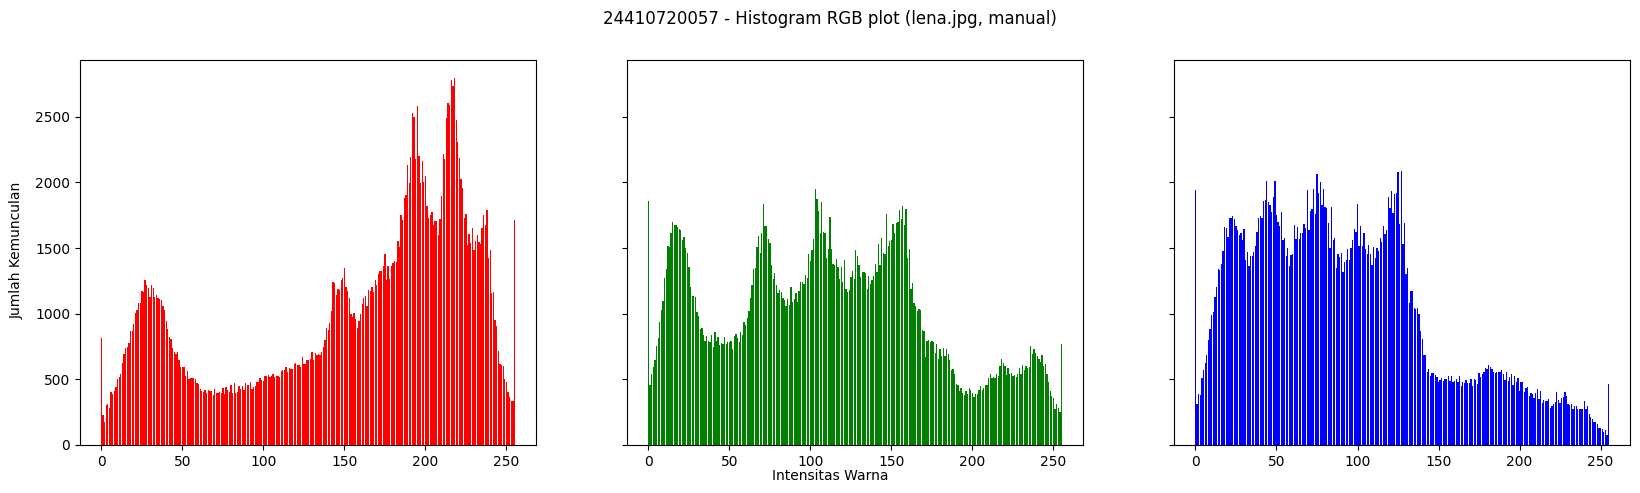

In [ ]:
#Tahap 1 citra contoh lena.jpg
img = safe_imread(f'{BASE}/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red   = [0] * 256
green = [0] * 256
blue  = [0] * 256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]]   += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]]  += 1

fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram RGB plot (lena.jpg, manual)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

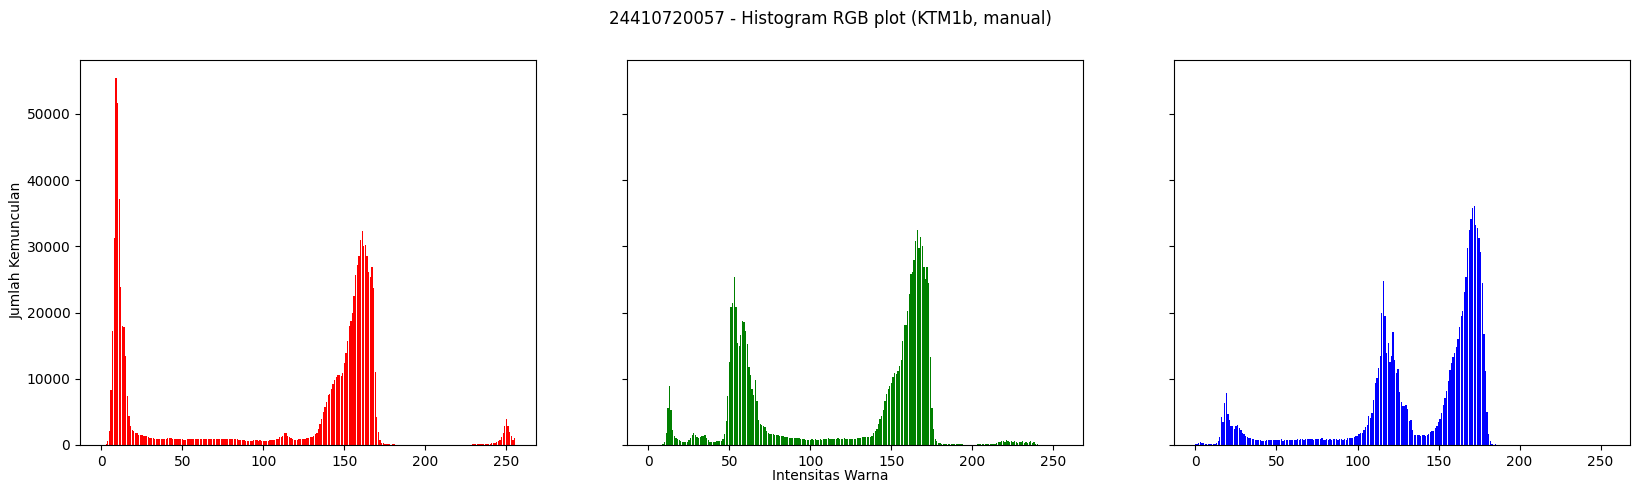

In [ ]:
# Tahap 2 citra KTM1b
img2 = safe_imread(f'{BASE}/KTM1b.jpeg')
img2 = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

height2, width2, depth2 = np.shape(img2)

red2   = [0] * 256
green2 = [0] * 256
blue2  = [0] * 256

for y in range(0, height2):
    for x in range(0, width2):
        red2[img2[y][x][0]]   += 1
        green2[img2[y][x][1]] += 1
        blue2[img2[y][x][2]]  += 1

fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram RGB plot (KTM1b, manual)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red2, color='red')
axs[1].bar(names, green2, color='green')
axs[2].bar(names, blue2, color='blue')
plt.show()

## **PERTANYAAN PRAKTIKUM E1**

1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.

In [ ]:
def hist_numpy(ch):
    h, _ = np.histogram(ch, bins=256, range=(0, 256))
    return h


def hist_cv(ch):
    return cv.calcHist([ch], [0], None, [256], [0, 256]).flatten().astype(int)


def bandingkan(bgr_img, manual_rgb, judul):
    r_np, g_np, b_np = hist_numpy(bgr_img[:, :, 2]), hist_numpy(bgr_img[:, :, 1]), hist_numpy(bgr_img[:, :, 0])
    r_cv, g_cv, b_cv = hist_cv(bgr_img[:, :, 2]), hist_cv(bgr_img[:, :, 1]), hist_cv(bgr_img[:, :, 0])
    rm, gm, bm = [np.array(c) for c in manual_rgb]
    print(f'=== {judul} ===')
    print('Manual vs NumPy (R,G,B):', np.max(np.abs(rm - r_np)), np.max(np.abs(gm - g_np)), np.max(np.abs(bm - b_np)))
    print('Manual vs CV    (R,G,B):', np.max(np.abs(rm - r_cv)), np.max(np.abs(gm - g_cv)), np.max(np.abs(bm - b_cv)))
    print('NumPy  vs CV    (R,G,B):', np.max(np.abs(r_np - r_cv)), np.max(np.abs(g_np - g_cv)), np.max(np.abs(b_np - b_cv)))


bandingkan(safe_imread(f'{BASE}/lena.jpg'),   (red, green, blue),    'lena.jpg')
bandingkan(safe_imread(f'{BASE}/KTM1b.jpg'),  (red2, green2, blue2), 'KTM1b.jpg - ' + NIM)

=== lena.jpg ===
Manual vs NumPy (R,G,B): 0 0 0
Manual vs CV    (R,G,B): 0 0 0
NumPy  vs CV    (R,G,B): 0 0 0
Info: dibaca dari /content/drive/MyDrive/PCVK 244107020057/KTM1b.jpeg (bukan /content/drive/MyDrive/PCVK 244107020057/KTM1b.jpg)
=== KTM1b.jpg - 24410720057 ===
Manual vs NumPy (R,G,B): 0 0 0
Manual vs CV    (R,G,B): 0 0 0
NumPy  vs CV    (R,G,B): 0 0 0


2.  Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.

Info: dibaca dari /content/drive/MyDrive/PCVK 244107020057/KTM1a.jpeg (bukan /content/drive/MyDrive/PCVK 244107020057/KTM1a.jpg)
Info: dibaca dari /content/drive/MyDrive/PCVK 244107020057/KTM1b.jpeg (bukan /content/drive/MyDrive/PCVK 244107020057/KTM1b.jpg)
Info: dibaca dari /content/drive/MyDrive/PCVK 244107020057/KTM1c.jpeg (bukan /content/drive/MyDrive/PCVK 244107020057/KTM1c.jpg)
Info: dibaca dari /content/drive/MyDrive/PCVK 244107020057/KTM1d.jpeg (bukan /content/drive/MyDrive/PCVK 244107020057/KTM1d.jpg)


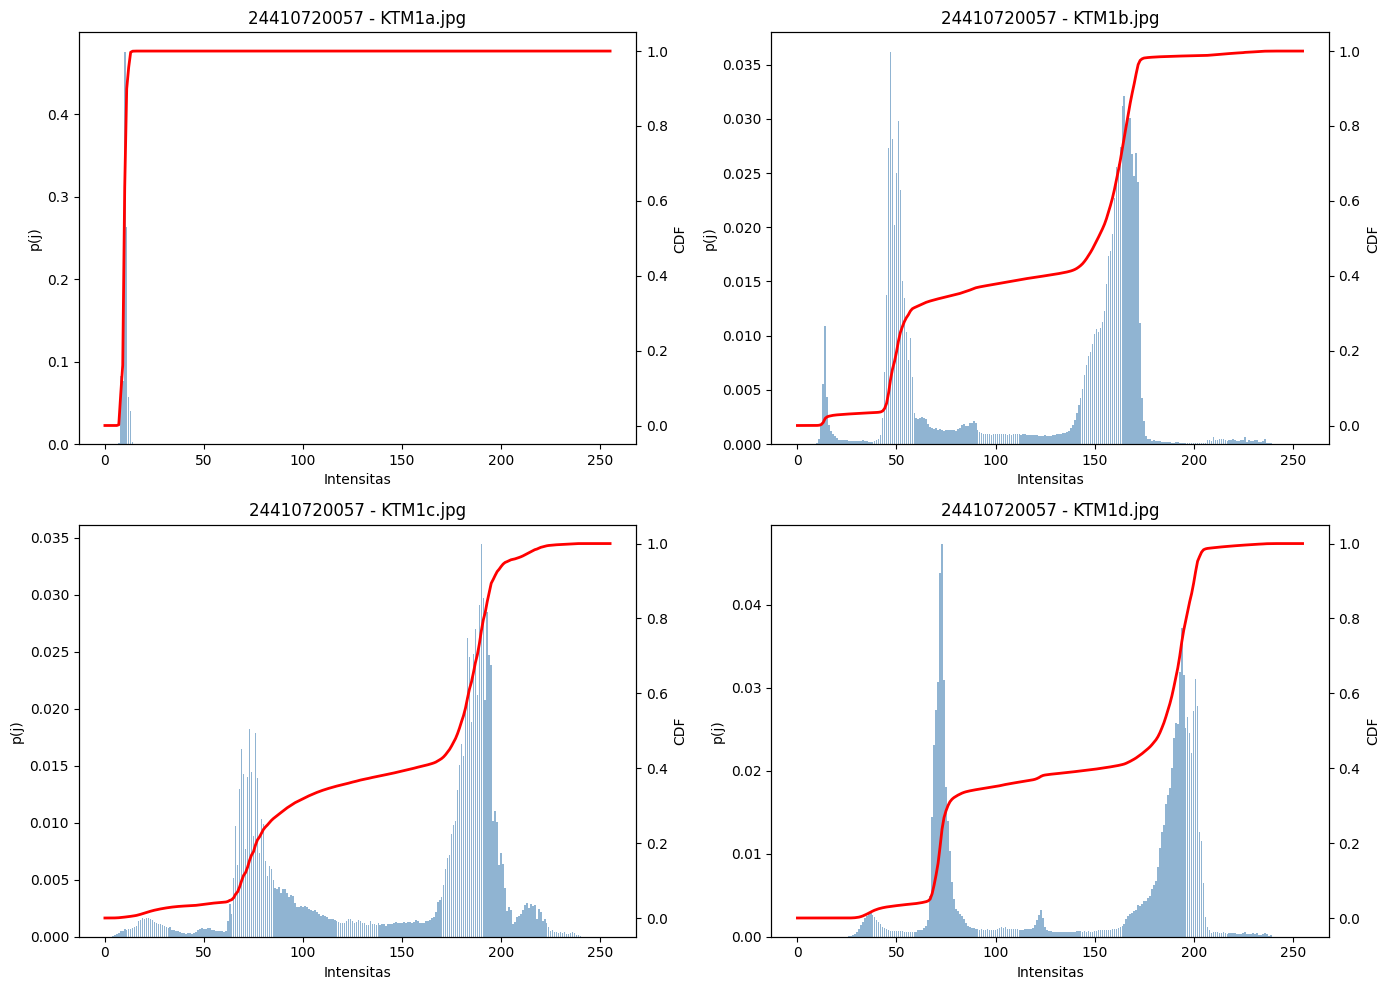

Rerata intensitas (gelap -> terang):
  KTM1a.jpg: 10.26
  KTM1b.jpg: 119.41
  KTM1d.jpg: 145.93
  KTM1c.jpg: 145.94


In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.ravel()
rerata_intensitas = {}

for i, fname in enumerate(['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']):
    gray = cv.cvtColor(safe_imread(f'{BASE}/{fname}'), cv.COLOR_BGR2GRAY)
    h, _ = np.histogram(gray, bins=256, range=(0, 256))
    p = h / gray.size
    cdf = np.cumsum(p)

    ax2 = axs[i].twinx()
    axs[i].bar(names, p, color='steelblue', alpha=0.6)
    ax2.plot(names, cdf, color='red', linewidth=2)
    axs[i].set_title(NIM + f' - {fname}')
    axs[i].set_xlabel('Intensitas'); axs[i].set_ylabel('p(j)'); ax2.set_ylabel('CDF')
    rerata_intensitas[fname] = gray.mean()

plt.tight_layout()
plt.show()

print('Rerata intensitas (gelap -> terang):')
for k, v in sorted(rerata_intensitas.items(), key=lambda kv: kv[1]):
    print(f'  {k}: {v:.2f}')

3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan
256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang
ketika jumlah bin dikurangi.

Info: dibaca dari /content/drive/MyDrive/PCVK 244107020057/KTM1b.jpeg (bukan /content/drive/MyDrive/PCVK 244107020057/KTM1b.jpg)


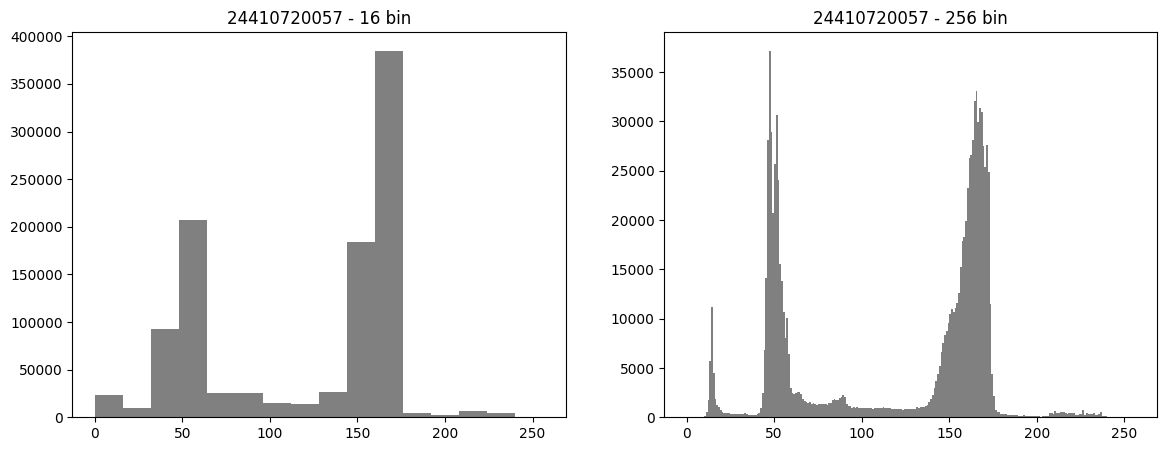

In [ ]:
gray_b = cv.cvtColor(safe_imread(f'{BASE}/KTM1b.jpg'), cv.COLOR_BGR2GRAY)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(gray_b.ravel(), bins=PARAM['bins'], range=(0, 256), color='gray')
ax[0].set_title(NIM + f" - {PARAM['bins']} bin")
ax[1].hist(gray_b.ravel(), bins=256, range=(0, 256), color='gray')
ax[1].set_title(NIM + ' - 256 bin')
plt.show()

#E-2 PERCOBAAN HISTOGRAM EQUALIZATION

In [ ]:
def he_channel(ch):
    """HE manual satu kanal: K0 = round((L-1) * CDF)."""
    h_hist, _ = np.histogram(ch, bins=256, range=(0, 256))
    p = h_hist / ch.size
    cdf = np.cumsum(p)
    Ko = np.round(cdf * 255).astype(np.uint8)
    return Ko[ch]


def he_manual_color(bgr_img):
    b, g, r = cv.split(bgr_img)
    return cv.merge([he_channel(b), he_channel(g), he_channel(r)])


def he_cv_color(bgr_img):
    b, g, r = cv.split(bgr_img)
    return cv.merge([cv.equalizeHist(b), cv.equalizeHist(g), cv.equalizeHist(r)])


def PSNR(a, b):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    return float('inf') if mse == 0 else 20 * math.log10(255.0 / math.sqrt(mse))

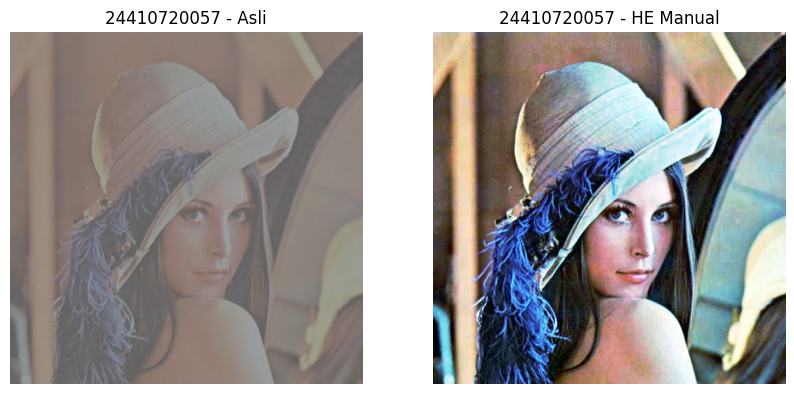

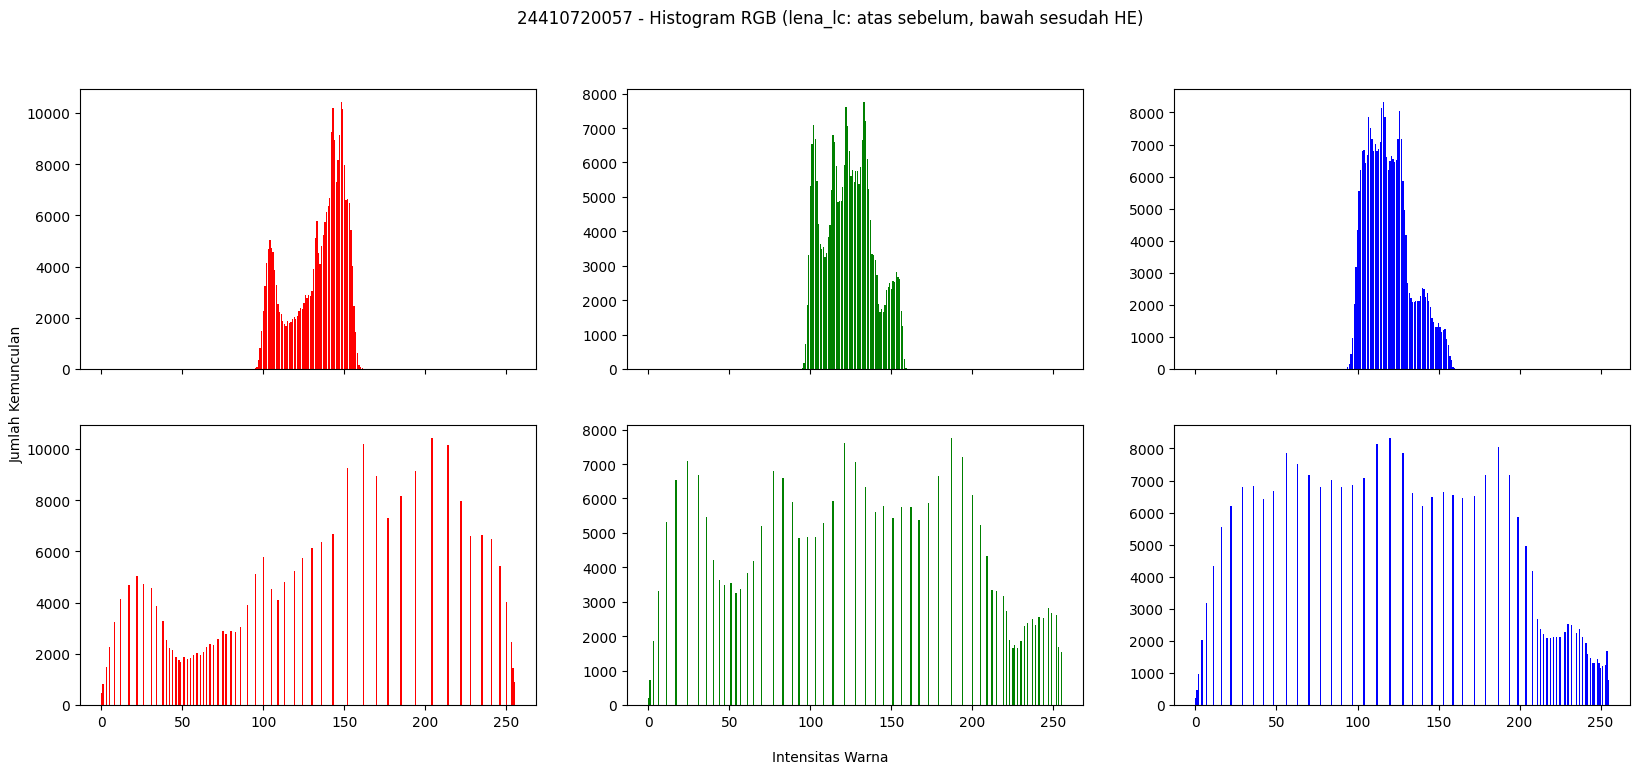

In [ ]:
bgr_lc = safe_imread(f'{BASE}/lena_lc.jpg')
he_manual_lena = he_manual_color(bgr_lc)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv.cvtColor(bgr_lc, cv.COLOR_BGR2RGB)); ax[0].set_title(NIM + ' - Asli'); ax[0].axis('off')
ax[1].imshow(cv.cvtColor(he_manual_lena, cv.COLOR_BGR2RGB)); ax[1].set_title(NIM + ' - HE Manual'); ax[1].axis('off')
plt.show()

fig, axs = plt.subplots(2, 3, figsize=[20, 8], sharex=True)
fig.suptitle(NIM + ' - Histogram RGB (lena_lc: atas sebelum, bawah sesudah HE)')
for j, (kanal_idx, warna) in enumerate([(2, 'red'), (1, 'green'), (0, 'blue')]):
    axs[0, j].bar(names, histogram_manual(bgr_lc[:, :, kanal_idx]), color=warna)
    axs[1, j].bar(names, histogram_manual(he_manual_lena[:, :, kanal_idx]), color=warna)
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
plt.show()

Info: dibaca dari /content/drive/MyDrive/PCVK 244107020057/KTM1b.jpeg (bukan /content/drive/MyDrive/PCVK 244107020057/KTM1b.jpg)


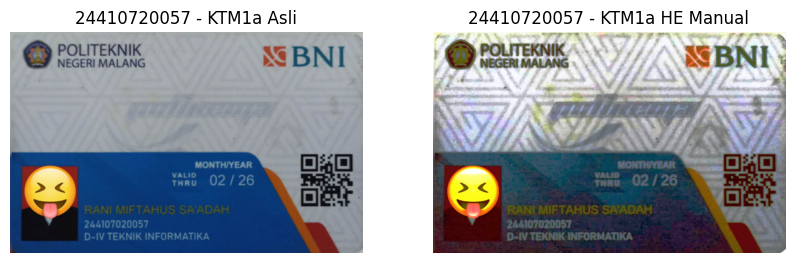

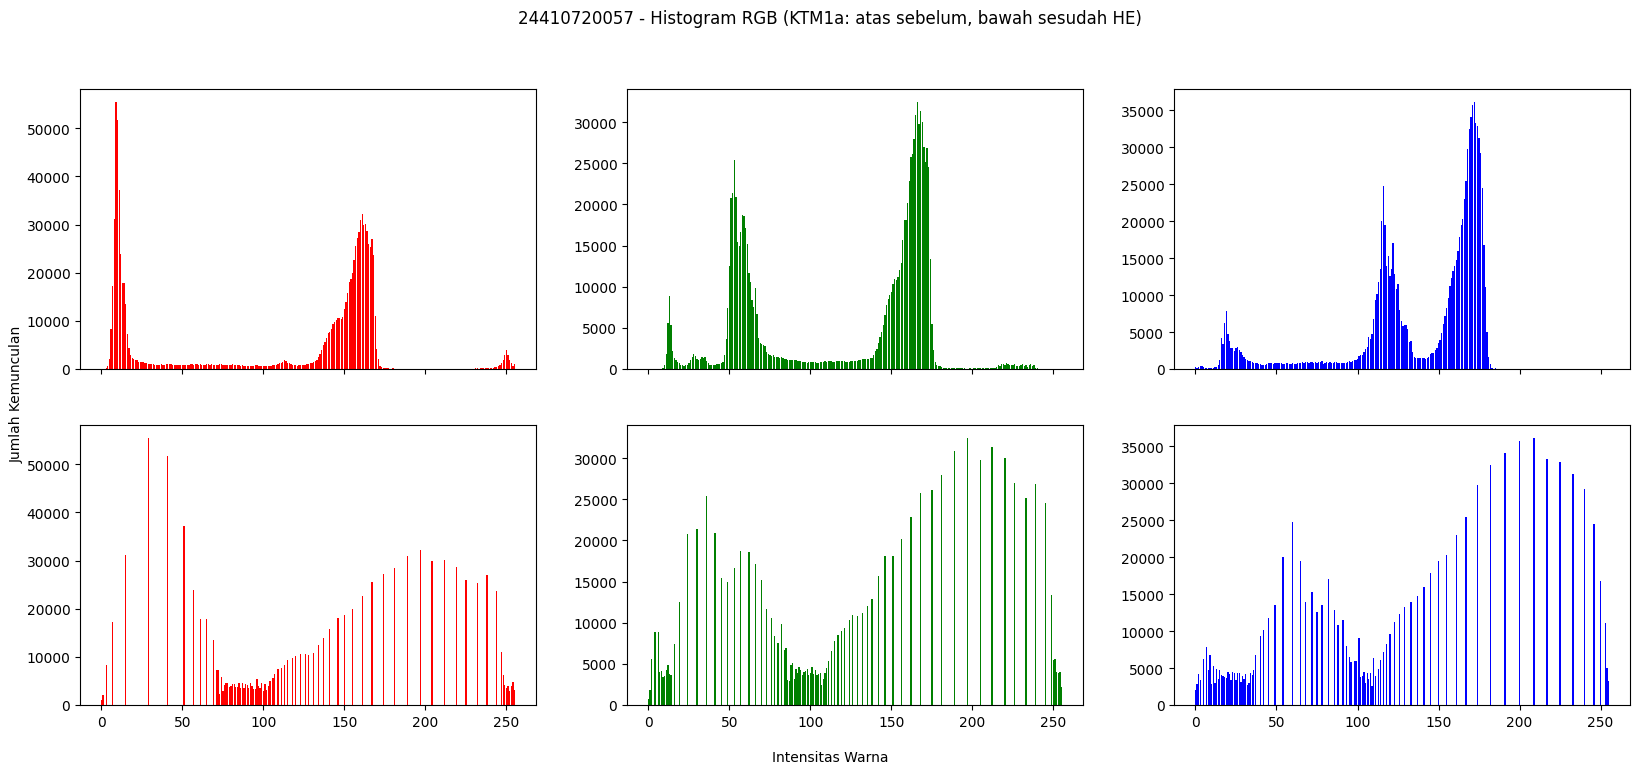

In [ ]:
bgr_ktm1a = safe_imread(f'{BASE}/KTM1b.jpg')
he_manual_ktm1a = he_manual_color(bgr_ktm1a)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv.cvtColor(bgr_ktm1a, cv.COLOR_BGR2RGB)); ax[0].set_title(NIM + ' - KTM1a Asli'); ax[0].axis('off')
ax[1].imshow(cv.cvtColor(he_manual_ktm1a, cv.COLOR_BGR2RGB)); ax[1].set_title(NIM + ' - KTM1a HE Manual'); ax[1].axis('off')
plt.show()

fig, axs = plt.subplots(2, 3, figsize=[20, 8], sharex=True)
fig.suptitle(NIM + ' - Histogram RGB (KTM1a: atas sebelum, bawah sesudah HE)')
for j, (kanal_idx, warna) in enumerate([(2, 'red'), (1, 'green'), (0, 'blue')]):
    axs[0, j].bar(names, histogram_manual(bgr_ktm1a[:, :, kanal_idx]), color=warna)
    axs[1, j].bar(names, histogram_manual(he_manual_ktm1a[:, :, kanal_idx]), color=warna)
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
plt.show()

Selisih maksimum lena_lc.jpg : 0
Selisih maksimum KTM1a.jpg   : 1


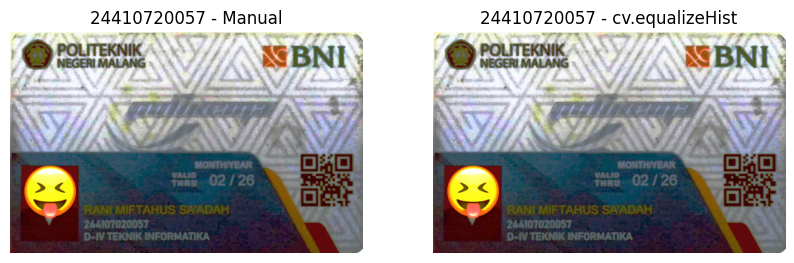

In [ ]:
b, g, r = cv.split(bgr_lc)
b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)
he_cv_lena = cv.merge([b_equalized, g_equalized, r_equalized])

selisih_lena = np.max(np.abs(he_manual_lena.astype(int) - he_cv_lena.astype(int)))
print('Selisih maksimum lena_lc.jpg :', selisih_lena)

he_cv_ktm1a = he_cv_color(bgr_ktm1a)
selisih_ktm1a = np.max(np.abs(he_manual_ktm1a.astype(int) - he_cv_ktm1a.astype(int)))
print('Selisih maksimum KTM1a.jpg   :', selisih_ktm1a)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv.cvtColor(he_manual_ktm1a, cv.COLOR_BGR2RGB)); ax[0].set_title(NIM + ' - Manual'); ax[0].axis('off')
ax[1].imshow(cv.cvtColor(he_cv_ktm1a, cv.COLOR_BGR2RGB)); ax[1].set_title(NIM + ' - cv.equalizeHist'); ax[1].axis('off')
plt.show()

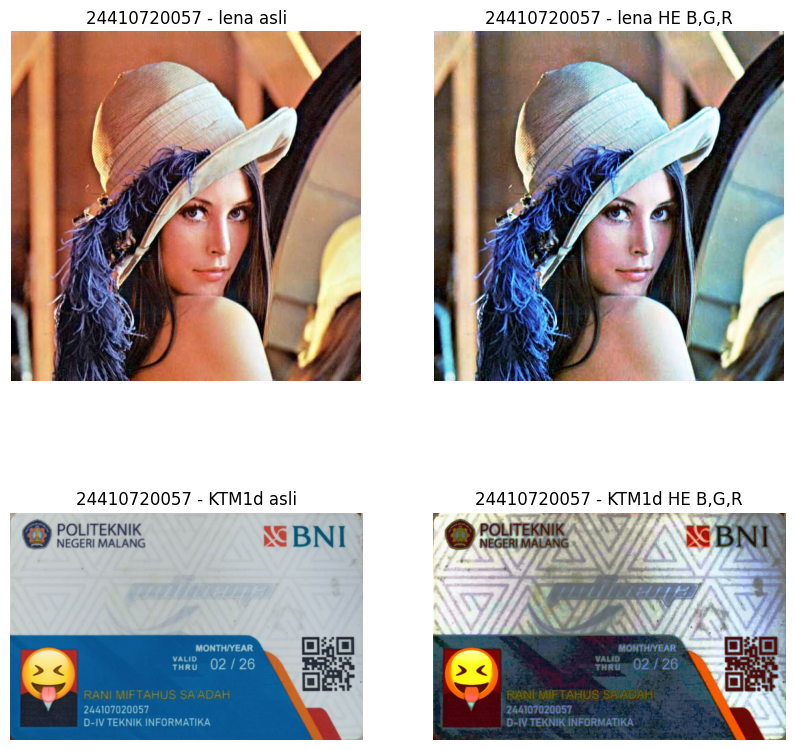

In [ ]:
def cara1(berkas):
    bgr = safe_imread(berkas)
    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    return bgr, cv.merge(kanal)


# Tahap 1: lena.jpg
bgr_l, he_rgb_l = cara1(CONTOH + '/lena.jpg')
# Tahap 2: KTM1d.jpeg
bgr, he_rgb = cara1(BASE + '/KTM1d.jpeg')

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax[0, 0].imshow(cv.cvtColor(bgr_l, cv.COLOR_BGR2RGB)); ax[0, 0].set_title(NIM + ' - lena asli')
ax[0, 1].imshow(cv.cvtColor(he_rgb_l, cv.COLOR_BGR2RGB)); ax[0, 1].set_title(NIM + ' - lena HE B,G,R')
ax[1, 0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB)); ax[1, 0].set_title(NIM + ' - KTM1d asli')
ax[1, 1].imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB)); ax[1, 1].set_title(NIM + ' - KTM1d HE B,G,R')
for a in ax.ravel():
    a.axis('off')
plt.show()

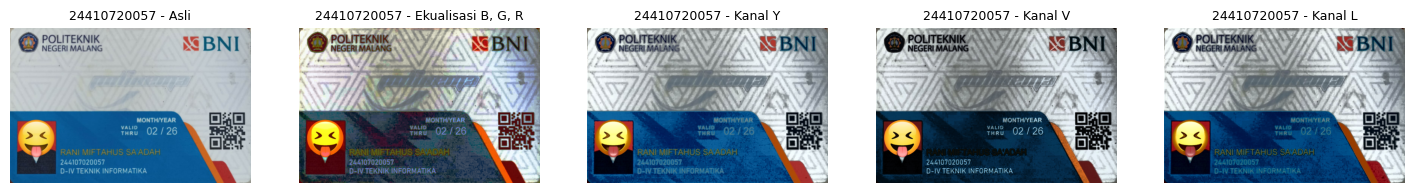

In [ ]:
ycrcb     = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

hsv       = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab       = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b   = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()

In [ ]:
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli,  cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)              # Hue melingkar 0-179
    return d.mean()


print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
    print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
                                  cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            145.9
Ekualisasi B, G, R                48.75            130.2
Kanal Y                            1.41            131.3
Kanal V                            1.77            115.3
Kanal L                            3.70            122.6


Kanal V + equalizeHist              : geser Hue = 1.77, terang = 115.3
Kanal V + CLAHE (clip=2.0, tile=3) : geser Hue = 0.79, terang = 140.0


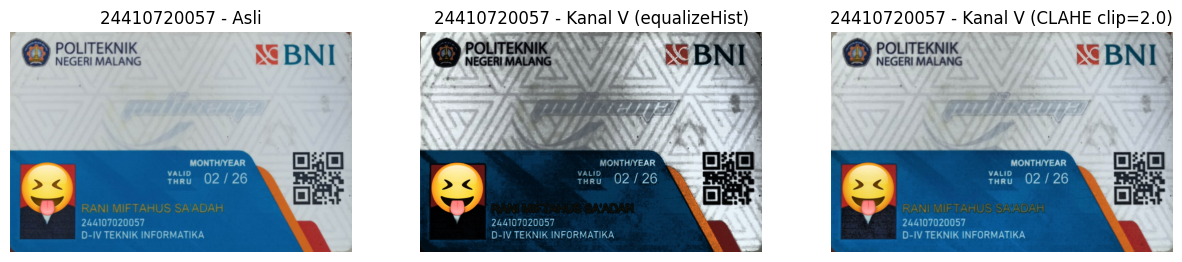

In [ ]:
clahe_v = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
he_v_clahe = cv.cvtColor(cv.merge([h, sat, clahe_v.apply(v)]), cv.COLOR_HSV2BGR)

print('Kanal V + equalizeHist              : geser Hue = %.2f, terang = %.1f' %
      (geser_hue(bgr, he_v) * 2, cv.cvtColor(he_v, cv.COLOR_BGR2GRAY).mean()))
print('Kanal V + CLAHE (clip=%.1f, tile=%d) : geser Hue = %.2f, terang = %.1f' %
      (PARAM['clip'], PARAM['tile'], geser_hue(bgr, he_v_clahe) * 2,
       cv.cvtColor(he_v_clahe, cv.COLOR_BGR2GRAY).mean()))

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a_, c, t in zip(ax, [bgr, he_v, he_v_clahe],
                    ['Asli', 'Kanal V (equalizeHist)', f"Kanal V (CLAHE clip={PARAM['clip']})"]):
    a_.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB)); a_.set_title(NIM + ' - ' + t); a_.axis('off')
plt.show()



### Tabel Hasil

| Cara ekualisasi | Rata-rata pergeseran Hue (derajat) | Rerata kecerahan sesudah | Catatan pengamatan visual |
|---|---|---|---|
| Citra asli | - | 145.9 | Kartu tampak pudar dan terlalu terang akibat cahaya matahari; kontras rendah, pola segitiga pada latar hampir tidak terlihat, area biru di bagian bawah tampak pucat. |
| Ekualisasi kanal B, G, R | 48.75 | 130.2 | Warna kartu berubah nyata: latar kartu bernuansa kehijauan/keruh dan area foto tampak lebih kemerahan dibanding aslinya, sehingga warna asli tidak lagi akurat. |
| Kanal Y (YCrCb) | 1.41 | 131.3 | Kontras naik, pola segitiga latar jelas terlihat, dan area biru bawah lebih pekat tanpa perubahan warna yang mencolok. |
| Kanal V (HSV) | 1.77 | 115.3 | Warna tetap terjaga, tetapi hasil paling gelap di antara semua cara; area biru bawah menjadi gelap sehingga tulisan nama lebih sulit dibaca. |
| Kanal L (LAB) | 3.70 | 122.6 | Kecerahan dan kontras meningkat, hasil mirip kanal Y tetapi sedikit lebih lembut, dengan pergeseran warna yang sedikit lebih terasa. |

### Jawaban Pertanyaan

**1. Cara mana yang menghasilkan pergeseran Hue paling besar, dan berapa nilainya pada citra saya?**

Ekualisasi kanal B, G, R menghasilkan pergeseran Hue paling besar, yaitu 48.75°. Nilai ini sekitar 35 kali lebih besar daripada kanal Y (1.41°), kanal V (1.77°), dan kanal L (3.70°). Penyebabnya, ketiga kanal diekualisasi sendiri-sendiri dengan fungsi transformasi yang berbeda-beda. Akibatnya rasio B:G:R pada tiap piksel, yang menentukan jenis warna, ikut berubah sehingga warna kartu bergeser jauh dari aslinya.

**2. Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis nol?**

Pada ekualisasi kanal Y, V, dan L, kanal warna (Cr/Cb, H/S, dan a/b) memang tidak diubah, tetapi pergeseran Hue tetap tidak nol (1.41°, 1.77°, dan 3.70°). Citra harus dikonversi ke ruang warna lain lalu dikembalikan ke BGR. Proses konversi dihitung dalam bilangan pecahan, sedangkan hasil akhirnya disimpan sebagai uint8. Nilai pecahan dibulatkan ke bilangan bulat, dan nilai yang keluar dari rentang 0-255 dipotong. Karena ekualisasi mengubah kecerahan cukup besar, sebagian piksel terbulatkan atau terpotong. Rasio R:G:B bergeser sedikit, sehingga Hue ikut bergeser kecil tetapi tidak sampai nol.

**3. Di antara kanal Y, V, dan L, mana yang paling sesuai untuk foto KTM saya?**

Kanal Y (YCrCb) paling sesuai. Pergeseran Hue-nya paling kecil (1.41°, dibanding V 1.77° dan L 3.70°), sehingga warna asli kartu paling terjaga. Kecerahannya (131.3) juga paling mendekati citra asli dibanding kanal V (115.3) dan L (122.6). Kanal V menghasilkan citra yang paling gelap sehingga area biru di bagian bawah kartu menjadi gelap. Dasar penilaian visualnya adalah tulisan nama dan NIM pada area biru bawah kartu serta pola segitiga pada latar kartu. Pada kanal Y, tulisan tersebut tampil dengan kontras yang lebih baik dan warna latar serta foto tetap mendekati aslinya, berbeda dengan ekualisasi B, G, R yang warnanya berubah jelas.

**4. Perbandingan kanal V dengan equalizeHist dan CLAHE (clipLimit = 2.0, tileGridSize = (3, 3))**

| Metode pada kanal V | Pergeseran Hue | Rerata kecerahan |
|---|---|---|
| equalizeHist | 1.77° | 115.3 |
| CLAHE (clip=2.0, tile=3) | 0.79° | 140.0 |

CLAHE menghasilkan pergeseran Hue yang lebih kecil (0.79° dibanding 1.77°, turun sekitar 55%) dan rerata kecerahan yang lebih dekat ke citra asli (140.0 dibanding 115.3; citra asli 145.9). equalizeHist bekerja secara global dan meregangkan seluruh rentang intensitas sekaligus. Akibatnya nilai piksel bergeser jauh dari aslinya, kecerahan turun banyak, dan lebih banyak nilai yang terbulatkan atau terpotong saat dikembalikan ke BGR. CLAHE bekerja per blok (3x3) dan membatasi penguatan kontras dengan clipLimit 2.0, sehingga perubahan tiap piksel lebih kecil dan warna lebih terjaga. Secara visual, hasil equalizeHist membuat pola latar kartu berbintik dan tulisan nama lebih gelap, sedangkan hasil CLAHE tampil lebih mirip citra asli dengan teks yang masih terbaca.

## **PERTANYAAN PRAKTIKUM E2**

1. Ekualisasi global pada citra KTM

In [ ]:
# ekualisasi global KTM1a grayscale + PSNR
gray_a = cv.cvtColor(safe_imread(f'{BASE}/KTM1b.jpg'), cv.COLOR_BGR2GRAY)
he_manual_a = he_channel(gray_a)                  # (a) manual
he_cv_a = cv.equalizeHist(gray_a)                 # (a) OpenCV
print('Selisih maks manual vs equalizeHist:', np.max(np.abs(he_manual_a.astype(int) - he_cv_a.astype(int))))

Info: dibaca dari /content/drive/MyDrive/PCVK 244107020057/KTM1b.jpeg (bukan /content/drive/MyDrive/PCVK 244107020057/KTM1b.jpg)
Selisih maks manual vs equalizeHist: 0


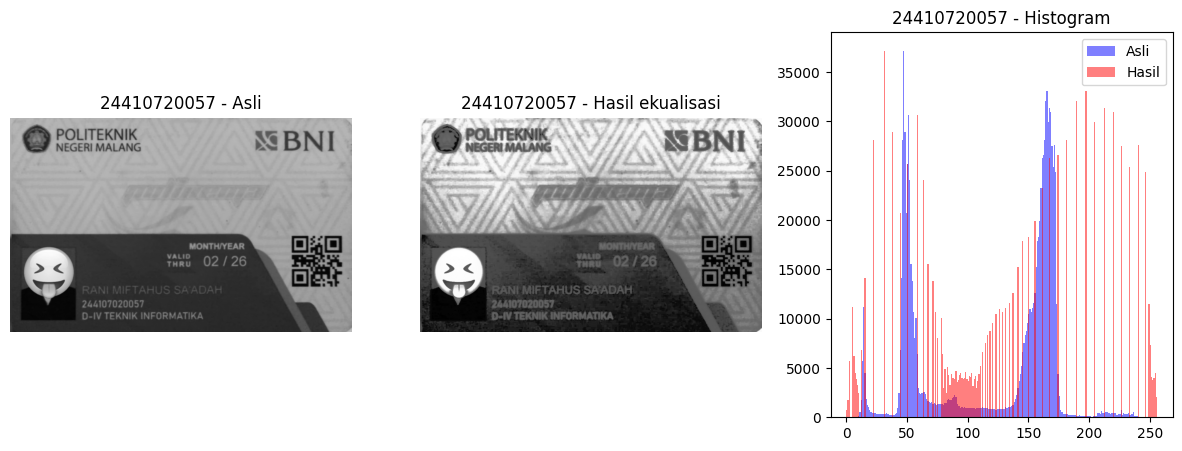

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(gray_a, cmap='gray'); axs[0].set_title(NIM + ' - Asli'); axs[0].axis('off')
axs[1].imshow(he_cv_a, cmap='gray'); axs[1].set_title(NIM + ' - Hasil ekualisasi'); axs[1].axis('off')
axs[2].hist(gray_a.ravel(), bins=256, range=(0, 256), alpha=0.5, color='blue', label='Asli')
axs[2].hist(he_cv_a.ravel(), bins=256, range=(0, 256), alpha=0.5, color='red', label='Hasil')
axs[2].legend(); axs[2].set_title(NIM + ' - Histogram')
plt.show()

In [ ]:
print('PSNR (asli vs hasil ekualisasi): %.2f dB' % PSNR(gray_a, he_cv_a))

PSNR (asli vs hasil ekualisasi): 17.92 dB


2. Ekualisasi lokal dengan CLAHE pada citra KTM

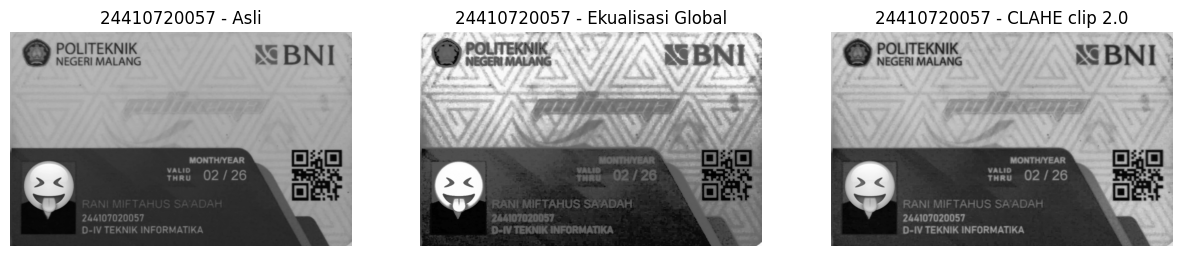

In [ ]:
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
he_clahe = clahe.apply(gray_a)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(gray_a, cmap='gray'); ax[0].set_title(NIM + ' - Asli')
ax[1].imshow(he_cv_a, cmap='gray'); ax[1].set_title(NIM + ' - Ekualisasi Global')
ax[2].imshow(he_clahe, cmap='gray'); ax[2].set_title(NIM + ' - CLAHE clip ' + str(PARAM['clip']))
for a_ in ax:
    a_.axis('off')
plt.show()

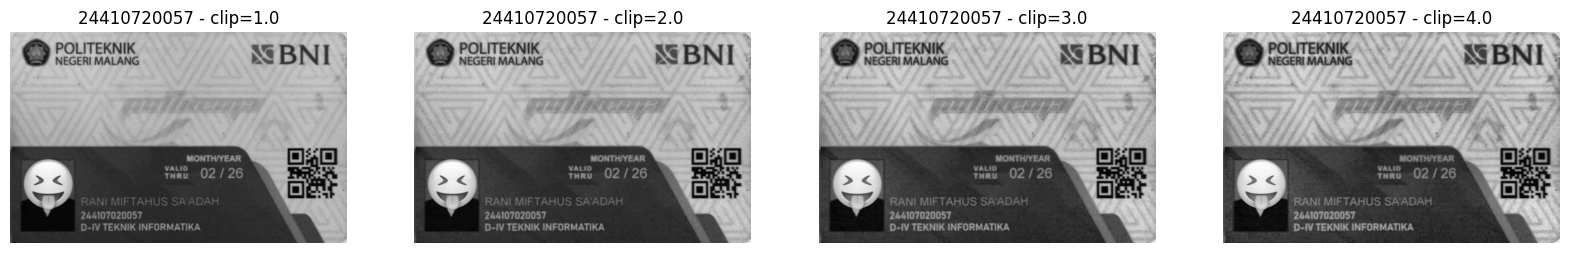

In [ ]:
clip_values = [1.0, PARAM['clip'], 3.0, 4.0]       # nilai Anda (2.0) + 3 lainnya
clip_values = list(dict.fromkeys(clip_values))      # buang duplikat, jaga urutan

fig, axs = plt.subplots(1, len(clip_values), figsize=(5 * len(clip_values), 5))
for a_, cval in zip(axs, clip_values):
    c = cv.createCLAHE(clipLimit=cval, tileGridSize=(PARAM['tile'], PARAM['tile']))
    a_.imshow(c.apply(gray_a), cmap='gray')
    a_.set_title(NIM + f' - clip={cval}'); a_.axis('off')
plt.show()

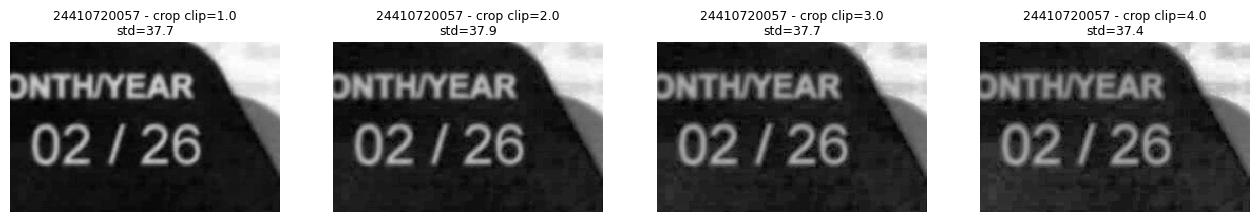

In [ ]:
H_img, W_img = gray_a.shape
y0, y1 = int(H_img * 0.55), int(H_img * 0.75)
x0, x1 = int(W_img * 0.55), int(W_img * 0.75)

fig, axs = plt.subplots(1, len(clip_values), figsize=(4 * len(clip_values), 4))
for a_, cval in zip(axs, clip_values):
    c = cv.createCLAHE(clipLimit=cval, tileGridSize=(PARAM['tile'], PARAM['tile']))
    crop = c.apply(gray_a)[y0:y1, x0:x1]
    a_.imshow(crop, cmap='gray', interpolation='nearest')
    a_.set_title(NIM + f' - crop clip={cval}\nstd={crop.std():.1f}', fontsize=9)
    a_.axis('off')
plt.show()

## **E-3 TUGAS PRAKTIKUM DITHERING**

In [ ]:
def floyd_steinberg(gray, L=2):
    img  = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:                 img[y,     x + 1] += error * 7 / 16
            if x > 0 and y + 1 < H:       img[y + 1, x - 1] += error * 3 / 16
            if y + 1 < H:                 img[y + 1, x    ] += error * 5 / 16
            if x + 1 < W and y + 1 < H:   img[y + 1, x + 1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)


def floyd_steinberg_color(bgr_img, L=2):
    b, g, r = cv.split(bgr_img)
    return cv.merge([floyd_steinberg(b, L), floyd_steinberg(g, L), floyd_steinberg(r, L)])

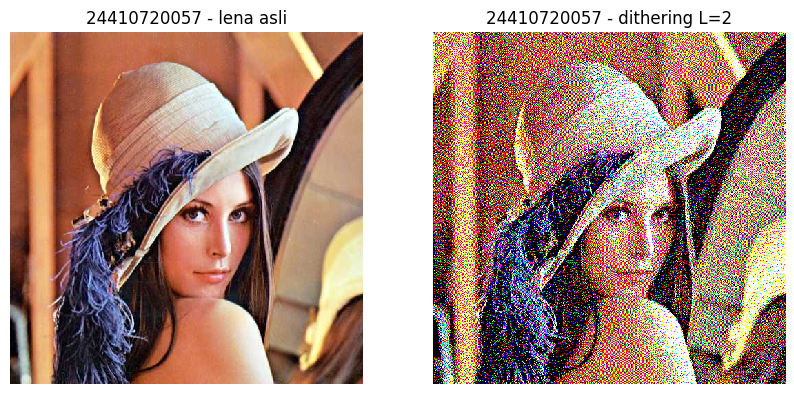

In [ ]:
bgr_lena = safe_imread(f'{BASE}/lena.jpg')
dither_lena = floyd_steinberg_color(bgr_lena, L=2)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv.cvtColor(bgr_lena, cv.COLOR_BGR2RGB), interpolation='nearest'); ax[0].set_title(NIM + ' - lena asli')
ax[1].imshow(cv.cvtColor(dither_lena, cv.COLOR_BGR2RGB), interpolation='nearest'); ax[1].set_title(NIM + ' - dithering L=2')
for a_ in ax:
    a_.axis('off')
plt.show()

Info: dibaca dari /content/drive/MyDrive/PCVK 244107020057/KTM1b.jpeg (bukan /content/drive/MyDrive/PCVK 244107020057/KTM1b.jpg)


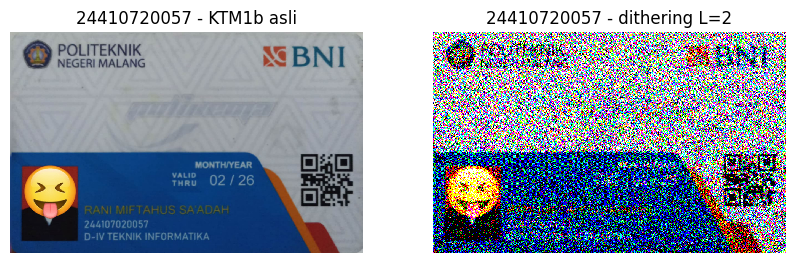

In [ ]:
bgr_b = safe_imread(f'{BASE}/KTM1b.jpg')
dither_b = floyd_steinberg_color(bgr_b, L=PARAM['L'])

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv.cvtColor(bgr_b, cv.COLOR_BGR2RGB), interpolation='nearest'); ax[0].set_title(NIM + ' - KTM1b asli')
ax[1].imshow(cv.cvtColor(dither_b, cv.COLOR_BGR2RGB), interpolation='nearest'); ax[1].set_title(NIM + f" - dithering L={PARAM['L']}")
for a_ in ax:
    a_.axis('off')
plt.show()

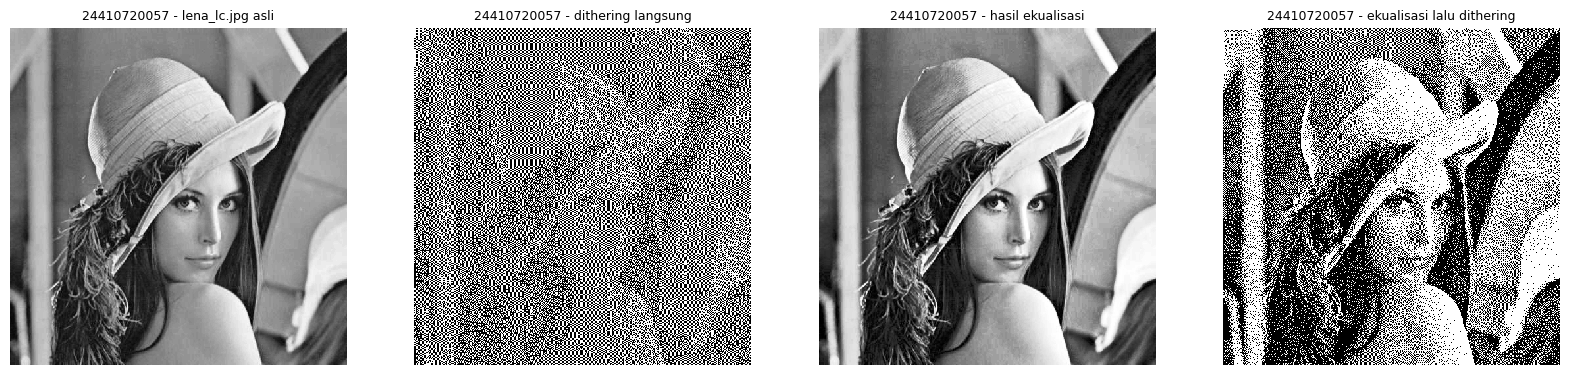

In [ ]:
def urutan_dithering(path, judul_img, L):
    gray = cv.cvtColor(safe_imread(path), cv.COLOR_BGR2GRAY)
    he = cv.equalizeHist(gray)
    d_langsung = floyd_steinberg(gray, L)
    d_he = floyd_steinberg(he, L)

    fig, ax = plt.subplots(1, 4, figsize=(20, 5))
    for a_, im, t in zip(ax, [gray, d_langsung, he, d_he],
                         [f'{judul_img} asli', 'dithering langsung', 'hasil ekualisasi', 'ekualisasi lalu dithering']):
        a_.imshow(im, cmap='gray', interpolation='nearest')
        a_.set_title(NIM + ' - ' + t, fontsize=9); a_.axis('off')
    plt.show()


urutan_dithering(f'{BASE}/lena_lc.jpg', 'lena_lc.jpg', L=2)

Info: dibaca dari /content/drive/MyDrive/PCVK 244107020057/KTM1b.jpeg (bukan /content/drive/MyDrive/PCVK 244107020057/KTM1b.jpg)


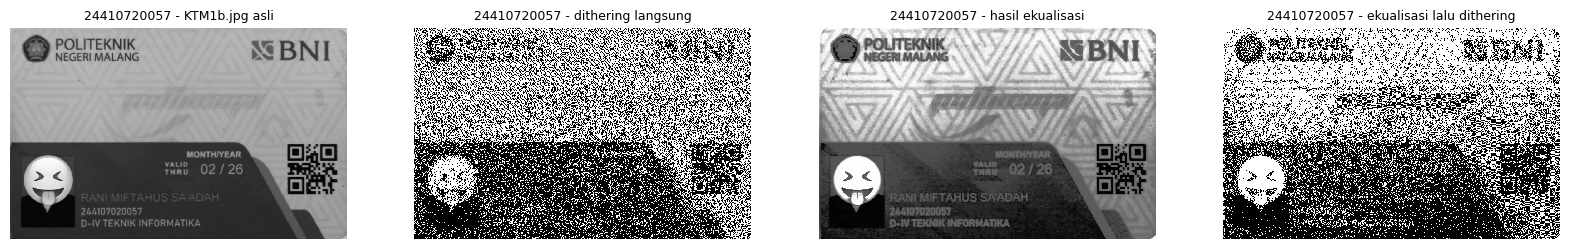

In [ ]:
urutan_dithering(f'{BASE}/KTM1b.jpg', 'KTM1b.jpg', L=PARAM['L'])

In [60]:
kecil = np.array([[200, 100,  50],
                  [120, 180,  90],
                  [ 60, 140, 220]], dtype=np.float32)
L_uji = PARAM['L']
step = 255.0 / (L_uji - 1)

In [61]:
lama = 200.0
baru = np.round(lama / step) * step
error = lama - baru
tangan = {
    (0, 1): 100 + error * 7 / 16,     # kanan
    (1, 0): 120 + error * 5 / 16,     # bawah
    (1, 1): 180 + error * 1 / 16,     # kanan-bawah
}
# (1,-1) untuk bobot 3/16 berada di luar citra (x=0) -> dilewati
print(f'lama={lama}, baru={baru}, error={error}')

lama=200.0, baru=255.0, error=-55.0


In [62]:
# Verifikasi dengan PROGRAM
im = kecil.copy()
y, x = 0, 0
H, W = im.shape
im[y, x] = baru
if x + 1 < W:                 im[y,     x + 1] += error * 7 / 16
if x > 0 and y + 1 < H:       im[y + 1, x - 1] += error * 3 / 16
if y + 1 < H:                 im[y + 1, x    ] += error * 5 / 16
if x + 1 < W and y + 1 < H:   im[y + 1, x + 1] += error * 1 / 16

for (yy, xx), nilai in tangan.items():
    print(f'piksel ({yy},{xx}): program={im[yy, xx]:.4f} | tangan={nilai:.4f}')
    assert np.isclose(im[yy, xx], nilai)
print('Verifikasi lolos. Error yang tersebar =', error * (7 + 5 + 1) / 16,
      '(bobot 3/16 hilang karena tetangga di luar batas citra)')

piksel (0,1): program=75.9375 | tangan=75.9375
piksel (1,0): program=102.8125 | tangan=102.8125
piksel (1,1): program=176.5625 | tangan=176.5625
Verifikasi lolos. Error yang tersebar = -44.6875 (bobot 3/16 hilang karena tetangga di luar batas citra)
